In [1]:
import pylbsr.notebooks
import pylbsr.misc

import pandas as pd
import matplotlib.pyplot as plt

import functools
import torch
import torch.nn as nn
import torch.utils.data
import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger, TensorBoardLogger
from dotmap import DotMap
from pathlib import Path
import yaml
from typing import Literal

import parnet
from parnet.layers import (
    AdditiveMix,
    LinearProjectionHead,
    MixCoeffMLP,
    MixCoeffPenalty,
)
from parnet.losses import MultinomialNLLLoss
from parnet.bin.train import LightningModel
from parnet_additional_utils import (
    load_parnet_model,
    load_parnet_model_from_statedict,
    ParnetModelName,
    save_parnet_model_as_statedict,
    GzListDataset,
)
from parnet.utils import count_trainable_params

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [2]:
_notebook_name = "02_train_globalclip_head.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[13:22:41] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
### SETUP

pylbsr.misc.set_seed(42)

torch.use_deterministic_algorithms(False)  # dilated convs have no deterministic CUDA kernel

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[13:22:42] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.08 s (00:00:00)


In [ ]:
### PARAMETERS

# ── Task / data configuration ──────────────────────────────────────────────────
params_num_tasks = 1        # single globalCLIP track
params_seq_length = 600

params_valid_split: str = "valid"
params_use_filtered_data: bool = True


# ── Model ─────────────────────────────────────────────────────────────────────
pretrained_model_name = ParnetModelName.PARNET_7M_0_0   # or PARNET_21M_NONE / PARNET_21M_5_0
_model_tag = pretrained_model_name.value.replace("parnet.", "")   # "7m-0.0" or "21m-none"

# ── Fine-tuning strategy ───────────────────────────────────────────────────────
params_finetuning_strategy: Literal["head", "unfreeze_last_n_layers", "full"] = "head"
params_use_control: bool = False   # Phase 1: no control
params_unfreeze_last_layers_n: int = 2

# ── Training ──────────────────────────────────────────────────────────────────
params_batch_size: int = 64
params_max_epochs: int = 50
params_lr: float = 1e-3

# ── Run naming ────────────────────────────────────────────────────────────────
_ctrl_suffix = "ctrl" if params_use_control else "noctrl"
_data_suffix = "filtered" if params_use_filtered_data else "raw"

_strategy_suffix = (
    f"unfreeze_last_{params_unfreeze_last_layers_n}_layers"
    if params_finetuning_strategy == "unfreeze_last_n_layers"
    else params_finetuning_strategy
)
params_name_of_resulting_model = (
    f"parnet.{_model_tag}"
    f".{_strategy_suffix}"
    f".globalclip-lysate-noNHS"
    f".{_data_suffix}"
    f".{_ctrl_suffix}"
    f".ep{params_max_epochs}"
)

⏱ 0.00 s (00:00:00)


In [20]:
### LOAD FILEPATHS CONFIG

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p

FILEPATHS = DotMap()

if params_use_filtered_data:
    FILEPATHS["data"] = _res(_fp_cfg["global_clip"]["data_lysate_noNHS_filtered"])
else:
    FILEPATHS["data"] = _res(_fp_cfg["global_clip"]["data_lysate_noNHS"])
    
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["output_dir"] = (
    PROJECT_DIR / "results" / "globalclip-head"
    / "training" / params_name_of_resulting_model
)

FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Data:             {FILEPATHS.data}")
logger.info(f"Pretrained model: {FILEPATHS.pretrained_model}")
logger.info(f"Output dir:       {FILEPATHS.output_dir}")

[14:45:08] INFO - Data:             /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt
INFO:02_train_globalclip_head.ipynb:Data:             /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt
[14:45:08] INFO - Pretrained model: /mnt/storage1/ml4rg26-shared/parnet-eclip/models-full-rbp-set/parnet.7m-0.0.pt
INFO:02_train_globalclip_head.ipynb:Pretrained model: /mnt/storage1/ml4rg26-shared/parnet-eclip/models-full-rbp-set/parnet.7m-0.0.pt
[14:45:08] INFO - Output dir:       /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50
INFO:02_train_globalclip_head.ipynb:Output dir:       /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.no

⏱ 0.02 s (00:00:00)


In [21]:
### SAVE RUN CONFIG FILE

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
_run_cfg = {
    "pretrained_model_name": pretrained_model_name.value,
    "params_finetuning_strategy": params_finetuning_strategy,
    "params_unfreeze_last_layers_n": params_unfreeze_last_layers_n,
    "params_use_control": params_use_control,
    "params_batch_size": params_batch_size,
    "params_max_epochs": params_max_epochs,
    "params_lr": params_lr,
    "params_seq_length": params_seq_length,
    "params_num_tasks": params_num_tasks,
    "params_valid_split": params_valid_split,
    "params_name_of_resulting_model": params_name_of_resulting_model,
    "dataset_path": str(FILEPATHS["data"]),
}
_run_cfg_path = FILEPATHS["output_dir"] / "run_config.yaml"
_run_cfg_path.write_text(yaml.dump(_run_cfg, default_flow_style=False))
logger.info(f"Saved run config → {_run_cfg_path}")

[14:45:11] INFO - Saved run config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/run_config.yaml
INFO:02_train_globalclip_head.ipynb:Saved run config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/run_config.yaml


⏱ 0.03 s (00:00:00)


In [22]:
### DATASET PREPARATION

train_ds = GzListDataset(
    FILEPATHS.data, split="train",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=True, mmap=True,
)
val_ds = GzListDataset(
    FILEPATHS.data, split=params_valid_split,
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

logger.info(f"Train size: {len(train_ds)}  |  Val size: {len(val_ds)}")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='train'... loaded 38695 samples.
Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='valid'... 

[14:45:35] INFO - Train size: 38695  |  Val size: 7266
INFO:02_train_globalclip_head.ipynb:Train size: 38695  |  Val size: 7266


loaded 7266 samples.
⏱ 20.90 s (00:00:20)


In [23]:
### LOAD PRETRAINED MODEL

model = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
logger.info(f"Loaded pretrained model — trainable params: {count_trainable_params(model):,}")
_head_conv = getattr(model.head.head_target, "pointwise", None) or getattr(
    model.head.head_target, "pointwise_conv", None
)
logger.info(f"Pretrained head num_tasks: {_head_conv.out_channels}")

[14:45:41] INFO - Loaded pretrained model — trainable params: 7,534,815
INFO:02_train_globalclip_head.ipynb:Loaded pretrained model — trainable params: 7,534,815
[14:45:41] INFO - Pretrained head num_tasks: 223
INFO:02_train_globalclip_head.ipynb:Pretrained head num_tasks: 223


⏱ 0.28 s (00:00:00)


In [ ]:
### MODEL ADAPTATION

class GlobalCLIPHead(nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        # (B, hidden_dim, 600) -> (B, num_tasks, 600)
        logit = self.projection(inputs)
        # normalize to log-probabilities along sequence dimension
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = train_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    _hidden_dim = _backbone_out.shape[1]
    model.head(_backbone_out)

logger.info(f"Backbone hidden dim: {_hidden_dim}")
logger.info(f"Replaced head — trainable params now: {count_trainable_params(model):,}")
print(model.head)
logger.info(f"New head out_channels: {model.head.projection.pointwise.out_channels}")

[14:45:43] INFO - Replaced head — trainable params now: 7,118,336
INFO:02_train_globalclip_head.ipynb:Replaced head — trainable params now: 7,118,336
[14:45:43] INFO - New head out_channels: 1
INFO:02_train_globalclip_head.ipynb:New head out_channels: 1


GlobalCLIPHead(
  (projection): LinearProjectionHead(
    (pointwise): Conv1d(512, 1, kernel_size=(1,), stride=(1,), padding=same, bias=False)
  )
)
⏱ 0.01 s (00:00:00)


In [25]:
### FINETUNING STRATEGY

if params_finetuning_strategy == "head":
    for param in model.stem.parameters():
        param.requires_grad = False
    for param in model.body.parameters():
        param.requires_grad = False
    print(f"[head] Trainable params: {count_trainable_params(model):,}  (head only)")

elif params_finetuning_strategy == "unfreeze_last_n_layers":
    for param in model.parameters():
        param.requires_grad = False
    body_blocks = list(model.body.children())
    for block in body_blocks[-params_unfreeze_last_layers_n:]:
        for param in block.parameters():
            param.requires_grad = True
    for param in model.head.parameters():
        param.requires_grad = True
    print(
        f"[unfreeze_last_{params_unfreeze_last_layers_n}_layers] "
        f"Trainable params: {count_trainable_params(model):,}"
    )

elif params_finetuning_strategy == "full":
    for param in model.parameters():
        param.requires_grad = True
    print(f"[full] Trainable params: {count_trainable_params(model):,}")

# when using params_finetuning_strategy = "head", you should see a very small number — 
# just the 512 weights of the Conv1d(512, 1, kernel_size=1) in our head

[head] Trainable params: 512  (head only)
⏱ 0.00 s (00:00:00)


In [12]:
### TENSORBOARD LOGGING

%load_ext tensorboard
_tb_logdir = str(FILEPATHS["output_dir"] / "tensorboard_logs")
%tensorboard --logdir {_tb_logdir}

Launching TensorBoard...

⏱ 60.12 s (00:01:00)


In [26]:
### TRAINING SETUP

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)

optimizer_cls = functools.partial(torch.optim.AdamW, lr=params_lr)
lightning_model = LightningModel(
    model=model,
    loss_fn=MultinomialNLLLoss(),
    optimizer=optimizer_cls,
    use_control=False, # only affects metric logging, not the forward pass
)

⏱ 0.01 s (00:00:00)


In [27]:
from parnet_demo_utils import MetricHistory

metric_history = MetricHistory()

csv_logger = CSVLogger(save_dir=FILEPATHS["output_dir"], name="csv_logs")
tb_logger  = TensorBoardLogger(save_dir=FILEPATHS["output_dir"], name="tensorboard_logs")

trainer = pl.Trainer(
    default_root_dir=FILEPATHS["output_dir"],
    max_epochs=params_max_epochs,
    accelerator="gpu",
    devices=[params_gpu_index],
    log_every_n_steps=10,
    logger=[csv_logger, tb_logger],
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=FILEPATHS["output_dir"] / "checkpoints",
            monitor="val/loss",
            mode="min",
            save_top_k=1,
            save_last=True,
            filename="best",
        ),
        metric_history,
    ],
)

trainer.fit(
    lightning_model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path=None,  # or specify a checkpoint path to resume training, e.g. best.ckpt
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                 | Type               | Params | Mode 
--------------------------------------------------------------------
0 | model                | RBPNet             | 7.1 M  | train
1 | loss_fn              | MultinomialNLLLoss | 0      | train
2 | penalty_loss         | MeanMetric         | 0      | train
3 | train_metrics_losses | MetricCollection   | 0      | train
4 | train_metrics_eCLIP  | MetricCollection   | 0      | train
5 | val_metrics_losses   | MetricCollection   | 0      | train
6 | val_metrics_eCLIP    | MetricCollection   | 0      | train
--------------------------------------------------------------------
512       Trainable params
7.1 M     Non-trainable params
7.1 M     Total params
28.473    Total estimated model params size (MB)
72        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MeanMetric was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


⏱ 2018.16 s (00:33:38)


In [29]:
# ── Export best model ──────────────────────────────────────────────────────────
# Load best checkpoint (lowest val/loss) rather than last epoch weights
best_ckpt_path = FILEPATHS["output_dir"] / "checkpoints" / "best.ckpt"
best_checkpoint = torch.load(best_ckpt_path, map_location=device)
lightning_model.load_state_dict(best_checkpoint["state_dict"])
logger.info(f"Loaded best checkpoint from → {best_ckpt_path}")

output_model_path = FILEPATHS["output_dir"] / "model.statedict.pt"
torch.save({
    "state_dict": lightning_model.model.state_dict(),
    "model_config": {
        "parnet_model_name": pretrained_model_name.value,
        "head": "GlobalCLIPHead",
        "num_tasks": params_num_tasks,
        "finetuning_strategy": params_finetuning_strategy,
        "use_control": params_use_control,
    },
}, output_model_path)
logger.info(f"Saved best model → {output_model_path}")

[15:26:36] INFO - Loaded best checkpoint from → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/checkpoints/best.ckpt
INFO:02_train_globalclip_head.ipynb:Loaded best checkpoint from → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/checkpoints/best.ckpt
[15:26:36] INFO - Saved best model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt
INFO:02_train_globalclip_head.ipynb:Saved best model → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt


⏱ 0.36 s (00:00:00)


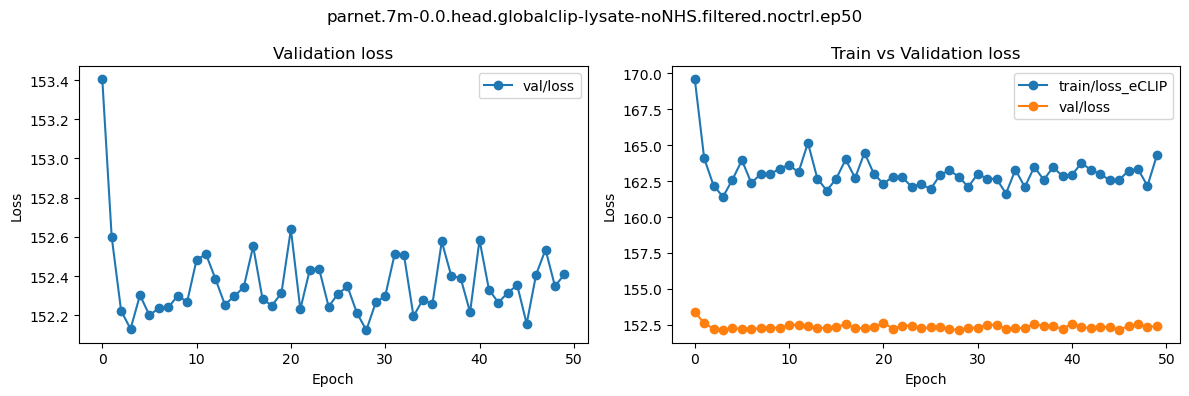

⏱ 0.69 s (00:00:00)


In [31]:
### LOSS CURVES

import pandas as pd
import matplotlib.pyplot as plt

_csv_path = sorted((FILEPATHS["output_dir"] / "csv_logs").glob("version_*/metrics.csv"))[-1]
df = pd.read_csv(_csv_path)

val   = df[['epoch', 'val/loss']].dropna(subset=['val/loss'])
train = df[['epoch', 'train/loss_eCLIP_epoch']].dropna(subset=['train/loss_eCLIP_epoch'])
summary = val.merge(train, on='epoch')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary['epoch'], summary['val/loss'], marker='o', label='val/loss')
axes[0].set_title('Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(summary['epoch'], summary['train/loss_eCLIP_epoch'], marker='o', label='train/loss_eCLIP')
axes[1].plot(summary['epoch'], summary['val/loss'], marker='o', label='val/loss')
axes[1].set_title('Train vs Validation loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle(params_name_of_resulting_model)
plt.tight_layout()

# ── Save to run folder and central figures dir ─────────────────────────────────
_figures_dir = PROJECT_DIR / "results" / "globalclip-head" / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(FILEPATHS["output_dir"] / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.savefig(_figures_dir / f"loss_curves.{params_name_of_resulting_model}.png", dpi=150, bbox_inches="tight")
plt.show()